# Contentsquare Website Analytics

## Project Overview

This project analyses user behaviour and website performance for an e-commerce storefront using data collected through Contentsquare.

The analysis examines overall website engagement, user progression through key website stages, funnel conversion and drop-off, and differences in user behaviour across the available Contentsquare data.

## Objectives

- Analyse overall website engagement and performance
- Examine key performance metrics such as sessions and bounce rate
- Analyse progression through the website funnel
- Identify conversion and drop-off points between key stages
- Examine the journey from the homepage through product listing and product detail pages to the cart
- Analyse available page-view and segment metrics
- Create visualisations to communicate the main findings
- Develop practical UX and business recommendations based on the analysis

## Data Source

The analysis uses data exported from Contentsquare during the project.

The available exports include key performance metrics, funnel data, dashboard metrics and segment-level data. The analysis is based on the metrics and dimensions contained within these exports.

## Analysis Approach

The analysis will:

1. Load and prepare the Contentsquare exports for analysis.
2. Examine overall website performance and engagement.
3. Analyse the user funnel and calculate conversion and drop-off between stages.
4. Examine available page-view and segment metrics.
5. Visualise the main patterns and performance indicators.
6. Interpret the findings and identify potential areas for improvement.
7. Develop UX and business recommendations based on the evidence in the data.

## Key Considerations

The analysis is based on the Contentsquare data available through the project exports. Conclusions are therefore limited to the metrics, stages and segments represented in the available data.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os

print(os.listdir())

['.git', '.ipynb_checkpoints', '2026-08-15-journey-analysis.png', 'ContentsquareAnalysis.ipynb', 'Key Performance Metrics-08_15_2026-Contentsquare.xlsx', 'New dashboard-08_15_2026-Contentsquare.xlsx', 'Segment-08_15_2026-Contentsquare.xlsx']


In [3]:
# Import Contentsquare data from Excel

key_metrics = pd.read_excel(
    "Key Performance Metrics-08_15_2026-Contentsquare.xlsx",
    sheet_name="Dashboard",
    header=None
)

dashboard = pd.read_excel(
    "New dashboard-08_15_2026-Contentsquare.xlsx",
    sheet_name="Dashboard",
    header=None
)

segment = pd.read_excel(
    "Segment-08_15_2026-Contentsquare.xlsx",
    sheet_name="Dashboard",
    header=None
)

In [5]:
# Extract key performance metrics

sessions = key_metrics.loc[
    key_metrics[0].eq("Number of sessions"), 1
].iloc[0]

bounce_rate = key_metrics.loc[
    key_metrics[0].eq("Bounce rate"), 1
].iloc[0]

print("Total sessions:", sessions)
print("Bounce rate:", bounce_rate)

Total sessions: 7
Bounce rate: 28.57


In [6]:
# Import funnel data from the Contentsquare Excel export

funnel_data = pd.read_excel(
    "New dashboard-08_15_2026-Contentsquare.xlsx",
    sheet_name="Dashboard",
    header=None
)

# Select the rows containing the funnel steps
funnel = funnel_data[
    funnel_data[0].astype(str).str.startswith("Step ")
].copy()

# Rename the funnel columns
funnel = funnel.iloc[:, :5]
funnel.columns = [
    "Step",
    "Sessions",
    "Conversion Rate",
    "Drop-off Sessions",
    "Drop-off Rate"
]

# Convert numerical columns to numeric values
funnel["Sessions"] = pd.to_numeric(funnel["Sessions"], errors="coerce")
funnel["Conversion Rate"] = pd.to_numeric(funnel["Conversion Rate"], errors="coerce")
funnel["Drop-off Sessions"] = pd.to_numeric(funnel["Drop-off Sessions"], errors="coerce")
funnel["Drop-off Rate"] = pd.to_numeric(funnel["Drop-off Rate"], errors="coerce")

In [7]:
# Analyse session drop-off between funnel stages

funnel["Sessions Lost"] = funnel["Sessions"].shift(1) - funnel["Sessions"]

funnel["Drop-off %"] = (
    funnel["Sessions Lost"] / funnel["Sessions"].shift(1) * 100
)

funnel

,Step,Sessions,Conversion Rate,Drop-off Sessions,Drop-off Rate,Sessions Lost,Drop-off %
13,Step 0 - Homepage,7,100.00,NaN,NaN,NaN,NaN
14,Step 1 - Product Listing Pages,5,71.43,2.0,28.57,2.0,28.571429
15,Step 2 - Product Detail Pages,5,100.00,0.0,0.00,0.0,0.000000
16,Step 3 - Cart,2,40.00,3.0,60.00,3.0,60.000000


In [8]:
# Identify the funnel stage with the highest drop-off rate

largest_drop_off = funnel.loc[funnel["Drop-off %"].idxmax()]

print("Largest drop-off:", largest_drop_off["Step"])
print("Sessions lost:", int(largest_drop_off["Sessions Lost"]))
print("Drop-off rate:", round(largest_drop_off["Drop-off %"], 2), "%")

Largest drop-off: Step 3 - Cart
Sessions lost: 3
Drop-off rate: 60.0 %


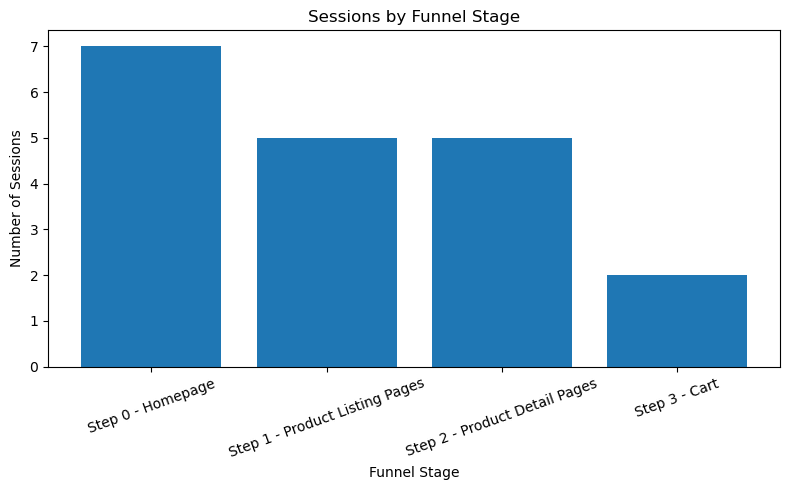

In [9]:
# Visualise sessions at each stage of the funnel

plt.figure(figsize=(8, 5))

plt.bar(funnel["Step"], funnel["Sessions"])

plt.title("Sessions by Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

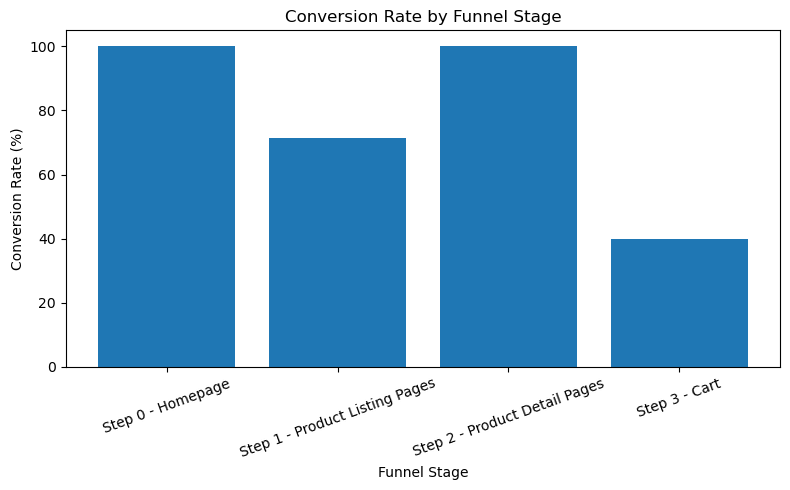

In [10]:
# Visualise conversion rate at each funnel stage

plt.figure(figsize=(8, 5))

plt.bar(funnel["Step"], funnel["Conversion Rate"])

plt.title("Conversion Rate by Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# Calculate overall homepage-to-cart conversion

homepage_sessions = funnel.loc[
    funnel["Step"].eq("Step 0 - Homepage"), "Sessions"
].iloc[0]

cart_sessions = funnel.loc[
    funnel["Step"].eq("Step 3 - Cart"), "Sessions"
].iloc[0]

overall_conversion = (cart_sessions / homepage_sessions) * 100

print("Homepage sessions:", int(homepage_sessions))
print("Cart sessions:", int(cart_sessions))
print("Overall homepage-to-cart conversion:", round(overall_conversion, 2), "%")

Homepage sessions: 7
Cart sessions: 2
Overall homepage-to-cart conversion: 28.57 %


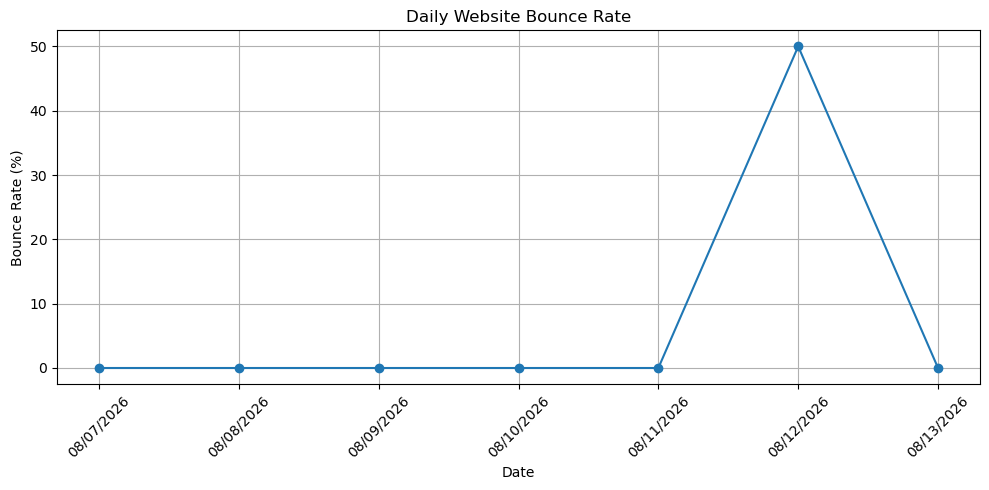

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_bounce["Date"],
    daily_bounce["Bounce_Rate"],
    marker="o"
)

plt.title("Daily Website Bounce Rate")
plt.xlabel("Date")
plt.ylabel("Bounce Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Device performance

device_sessions = kpi_raw.loc[32, 1]
device_bounce = kpi_raw.loc[75, 1]

print("Device Performance")
print("------------------")
print("Desktop sessions:", device_sessions)
print("Desktop bounce rate:", device_bounce, "%")

Device Performance
------------------
Desktop sessions: 3
Desktop bounce rate: 33.33 %


In [15]:
# Key website performance findings

peak_sessions = daily_sessions.loc[daily_sessions["Sessions"].idxmax()]
peak_bounce = daily_bounce.loc[daily_bounce["Bounce_Rate"].idxmax()]

print("Key Website Performance Findings")
print("---------------------------------")
print(f"Total sessions: {total_sessions}")
print(f"Overall bounce rate: {bounce_rate:.2f}%")
print(f"Views per session: {views_per_session:.2f}")
print(f"Average session time: {session_time:.2f} seconds")
print(f"Peak sessions: {int(peak_sessions['Sessions'])} on {peak_sessions['Date']}")
print(f"Peak bounce rate: {peak_bounce['Bounce_Rate']:.2f}% on {peak_bounce['Date']}")

Key Website Performance Findings
---------------------------------
Total sessions: 3
Overall bounce rate: 33.33%
Views per session: 24.67
Average session time: 756.53 seconds
Peak sessions: 2 on 08/12/2026
Peak bounce rate: 50.00% on 08/12/2026


## Key Findings

The Contentsquare data shows limited but useful website activity during the observation period.

- The website recorded 3 sessions during the reporting period.
- The overall bounce rate was 33.33%.
- Average views per session were 24.67.
- Average session time was approximately 12.6 minutes.
- The highest daily activity occurred on 12 August, with 2 sessions.
- The highest daily bounce rate was 50% on 12 August.
- All recorded sessions were from desktop devices.

### Interpretation

Due to the small number of recorded sessions, these results should be treated as directional rather than statistically representative. However, the data demonstrates how Contentsquare can be used to monitor website engagement, identify changes in traffic behaviour and support UX-focused analysis.